In [117]:
import pandas as pd

df = pd.read_csv('/Users/ekaterinastepura/Downloads/df_labeled_all_final22.csv')

In [118]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [119]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        27996
уличное пространство                                                                                                                    4459
жилое помещение, уличное пространство                                                                                                   1552
другое                                                                                                                                  1231
жилое помещение, подъезд и прилегающие зоны                                                                                              494
общественное место                                                                                                                       417
подъезд и прилегающие зоны                                                                                                               399
обще

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37755 entries, 0 to 37754
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        37755 non-null  int64  
 1   judge                     37755 non-null  object 
 2   decision                  37755 non-null  object 
 3   gender_accused            37749 non-null  object 
 4   prior_convictions         37750 non-null  object 
 5   alcohol                   37755 non-null  object 
 6   precrime_argument         37755 non-null  int64  
 7   has_woman_victim          37755 non-null  int64  
 8   has_man_victim            37755 non-null  float64
 9   method                    37755 non-null  object 
 10  motive                    37755 non-null  object 
 11  location                  37755 non-null  object 
 12  prison_term               37585 non-null  float64
 13  many_victims              37755 non-null  int64  
 14  year  

In [121]:
df.iloc[2][2]

/var/folders/v9/t047yh610c99k7c6cfrwyppr0000gn/T/ipykernel_52598/870244984.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[2][2]


'Вынесен ПРИГОВОР'

In [122]:
df.loc[:, "gender_accused"] = df["gender_accused"].map({"мужчина": 1, "женщина": 0})
df.loc[:, "prior_convictions"] = df["prior_convictions"].map({"да": 1, "нет": 0})
df.loc[:, "alcohol"] = df["alcohol"].map({"да": 1, "нет": 0})

In [124]:
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [125]:
categorical = ['season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

In [126]:
df['prior_convictions'].value_counts()

prior_convictions
0.0    32048
1.0     5690
Name: count, dtype: int64

In [127]:
!pip install optuna -q

In [129]:
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score

def objective(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'class_weights': [1, trial.suggest_float('class_weight_positive', 1.0, 5.0)],
        'eval_metric': 'F1',
        'cat_features': categorical_features,
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=0)
    
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    return f1

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=70)

print('Лучшие параметры:', study.best_params)

[I 2025-04-28 15:48:48,180] A new study created in memory with name: no-name-54c0873a-a51d-423e-8ef1-3722dbcfa4b7
[I 2025-04-28 15:48:50,661] Trial 0 finished with value: 0.5012799627647195 and parameters: {'learning_rate': 0.10268824623210823, 'depth': 8, 'l2_leaf_reg': 2.5481519442723153, 'random_strength': 5.7414464744512, 'bagging_temperature': 0.22694252814126326, 'border_count': 200, 'class_weight_positive': 4.562033943493868}. Best is trial 0 with value: 0.5012799627647195.
[I 2025-04-28 15:48:52,958] Trial 1 finished with value: 0.5241614553723707 and parameters: {'learning_rate': 0.06699877090007295, 'depth': 7, 'l2_leaf_reg': 8.941274162031299, 'random_strength': 0.20267713583599067, 'bagging_temperature': 0.8039362829637613, 'border_count': 91, 'class_weight_positive': 2.9479155924954292}. Best is trial 1 with value: 0.5241614553723707.
[I 2025-04-28 15:48:54,242] Trial 2 finished with value: 0.48113914564076943 and parameters: {'learning_rate': 0.055817759827785765, 'depth'

Лучшие параметры: {'learning_rate': 0.2495970196549017, 'depth': 6, 'l2_leaf_reg': 4.267693335512659, 'random_strength': 2.725837906345858, 'bagging_temperature': 0.9059391768179174, 'border_count': 143, 'class_weight_positive': 3.2178342697057842}


In [ ]:
best_params = study.best_params

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    random_strength=best_params['random_strength'],
    bagging_temperature=best_params['bagging_temperature'],
    border_count=best_params['border_count'],
    class_weights=[1, best_params['class_weight_positive']],
    eval_metric='F1',
    cat_features=categorical_features,
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.6304774	test: 0.6346315	best: 0.6346315 (0)	total: 38.5ms	remaining: 38.5s
100:	learn: 0.6869693	test: 0.6511885	best: 0.6602657 (71)	total: 1.02s	remaining: 9.12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6602656907
bestIteration = 71

Shrink model to first 72 iterations.
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      5435
           1       0.47      0.61      0.53      1518

    accuracy                           0.76      6953
   macro avg       0.67      0.71      0.68      6953
weighted avg       0.79      0.76      0.77      6953



In [ ]:
import numpy as np

errors = (y_pred != y_test)
error_df = X_test[errors]
error_df['true_label'] = y_test[errors]
error_df['predicted_label'] = y_pred[errors]

print(f"Ошибочных предсказаний: {len(error_df)} из {len(y_test)} ({len(error_df)/len(y_test):.2%})")
error_df.sample(10)

Ошибочных предсказаний: 1652 из 6953 (23.76%)


/var/folders/v9/t047yh610c99k7c6cfrwyppr0000gn/T/ipykernel_52598/3605649190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  error_df['true_label'] = y_test[errors]
/var/folders/v9/t047yh610c99k7c6cfrwyppr0000gn/T/ipykernel_52598/3605649190.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  error_df['predicted_label'] = y_pred[errors]


,gender_accused,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,many_victims,year,season,attempt,...,location_ уличное пространство,location_другое,location_жилое помещение,location_общественное место,location_общественный транспорт,location_подъезд и прилегающие зоны,location_рабочая зона,location_уличное пространство,true_label,predicted_label
30422,1,1,0,0,1,8.610771,0,2022,Весна,0,...,0,0,1,0,0,0,0,0,1,0
5241,1,1,0,0,1,10.560141,0,2016,Осень,0,...,0,0,1,0,0,0,0,0,0,1
4981,1,1,0,0,1,12.392802,0,2016,Лето,0,...,0,0,0,0,0,0,0,1,0,1
13604,1,1,0,0,1,10.332487,0,2018,Весна,0,...,0,0,1,0,0,0,0,0,0,1
12895,1,1,0,0,1,8.895568,0,2018,Зима,0,...,0,0,0,0,0,0,0,1,1,0
16832,1,1,0,1,1,9.486743,0,2018,Зима,0,...,0,0,1,0,0,0,0,0,0,1
12864,1,1,0,0,1,9.732264,0,2018,Зима,0,...,0,0,1,0,0,0,0,0,0,1
21454,1,1,0,1,1,8.909913,0,2020,Весна,0,...,0,0,1,0,0,0,0,0,1,0
34654,1,1,0,1,0,9.847782,0,2023,Осень,1,...,0,0,0,0,0,1,0,0,0,1
32954,1,1,0,0,1,7.793683,0,2023,Зима,1,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
from catboost import CatBoostClassifier

# Сохраняем модель в файл
model.save_model("catboost_prior_convictions_model.cbm")

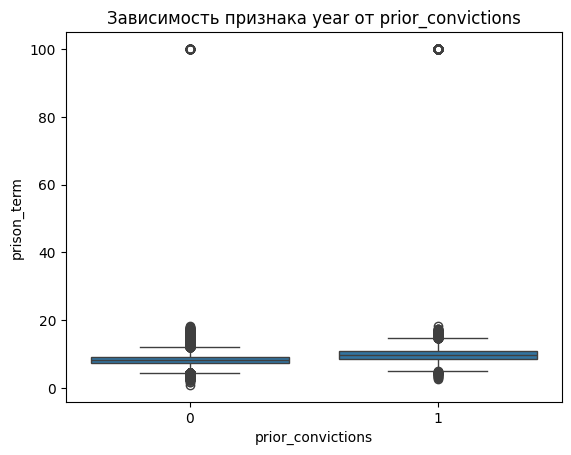

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='prior_convictions', y='prison_term', data=df)
plt.title('Зависимость признака year от prior_convictions')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('plots', exist_ok=True)


def plot_feature_importance(feature_names, feature_importances):
    fi = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
    fi = fi.sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=fi, palette='viridis')
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png')
    plt.close()

def plot_prison_term(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='prior_convictions', y='prison_term', data=df, palette='Set2')
    plt.title('Prison Term vs Prior Convictions')
    plt.xlabel('Prior Convictions')
    plt.ylabel('Prison Term (years)')
    plt.tight_layout()
    plt.savefig('plots/prison_term_vs_prior_convictions.png')
    plt.close()


def plot_region(df):
    region_crosstab = pd.crosstab(df['region_name'], df['prior_convictions'], normalize='index')
    region_crosstab = region_crosstab.sort_values(1, ascending=False).head(20)  # Топ-20

    region_crosstab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20c')
    plt.title('Prior Convictions Distribution by Region')
    plt.ylabel('Proportion')
    plt.xlabel('Region')
    plt.legend(title='Prior Convictions', loc='best')
    plt.tight_layout()
    plt.savefig('plots/region_vs_prior_convictions.png')
    plt.close()

def plot_attempt(df):
    attempt_crosstab = pd.crosstab(df['attempt'], df['prior_convictions'], normalize='index')

    attempt_crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='coolwarm')
    plt.title('Prior Convictions Distribution by Attempt')
    plt.ylabel('Proportion')
    plt.xlabel('Attempt (0=no, 1=yes)')
    plt.legend(title='Prior Convictions')
    plt.tight_layout()
    plt.savefig('plots/attempt_vs_prior_convictions.png')
    plt.close()

def plot_judge(df):
    judge_crosstab = pd.crosstab(df['judge'], df['prior_convictions'], normalize='index')
    judge_crosstab = judge_crosstab.sort_values(1, ascending=False).head(20)  # Топ-20 судей

    judge_crosstab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Pastel1')
    plt.title('Prior Convictions Distribution by Judge (Top 20)')
    plt.ylabel('Proportion')
    plt.xlabel('Judge')
    plt.legend(title='Prior Convictions')
    plt.tight_layout()
    plt.savefig('plots/judge_vs_prior_convictions.png')
    plt.close()


def plot_multilabel(df, column):
    # Проверяем, есть ли колонка
    if column not in df.columns:
        print(f"Column {column} not found!")
        return

    multilabel_crosstab = pd.crosstab(df[column], df['prior_convictions'], normalize='index')
    multilabel_crosstab = multilabel_crosstab.sort_values(1, ascending=False).head(20)

    multilabel_crosstab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab10')
    plt.title(f'Prior Convictions Distribution by {column.capitalize()}')
    plt.ylabel('Proportion')
    plt.xlabel(column.capitalize())
    plt.legend(title='Prior Convictions')
    plt.tight_layout()
    plt.savefig(f'plots/{column}_vs_prior_convictions.png')
    plt.close()

plot_feature_importance(feature_names, feature_importances)
plot_prison_term(df)
plot_region(df)
plot_attempt(df)
plot_judge(df)

plot_multilabel(df, 'method')
plot_multilabel(df, 'motive')
plot_multilabel(df, 'location')

print("Все графики сохранены в папку 'plots/'.")

/var/folders/v9/t047yh610c99k7c6cfrwyppr0000gn/T/ipykernel_52598/86332808.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=fi, palette='viridis')
/var/folders/v9/t047yh610c99k7c6cfrwyppr0000gn/T/ipykernel_52598/86332808.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prior_convictions', y='prison_term', data=df, palette='Set2')


Все графики сохранены в папку 'plots/'.


In [ ]:
ft = {}
for i, feature in enumerate(feature_names):
    ft[feature] = feature_importances[i]

In [ ]:
# Сортировка признаков по убыванию их важности
sorted_features = sorted(ft.items(), key=lambda x: x[1], reverse=True)

# Преобразуем в DataFrame для наглядности
sorted_features_df = pd.DataFrame(sorted_features, columns=['Feature', 'Importance'])

# Выведем отсортированный список
print(sorted_features_df)

                                 Feature  Importance
0                            prison_term   34.480647
1                            region_name   14.100298
2                                attempt    9.328166
3            method_огнестрельное оружие    6.973467
4                                 season    4.824163
5                                   year    4.698647
6                         gender_accused    2.923845
7                           many_victims    2.902388
8                                alcohol    1.879571
9                       has_woman_victim    1.731985
10                                 cruel    1.346493
11         location_уличное пространство    1.268785
12                 location_рабочая зона    1.207407
13         method_физическое воздействие    1.117126
14               motive_личная неприязнь    1.116480
15              victim_child_or_helpless    1.114248
16                method_холодное оружие    1.077936
17                        has_man_victim    1.

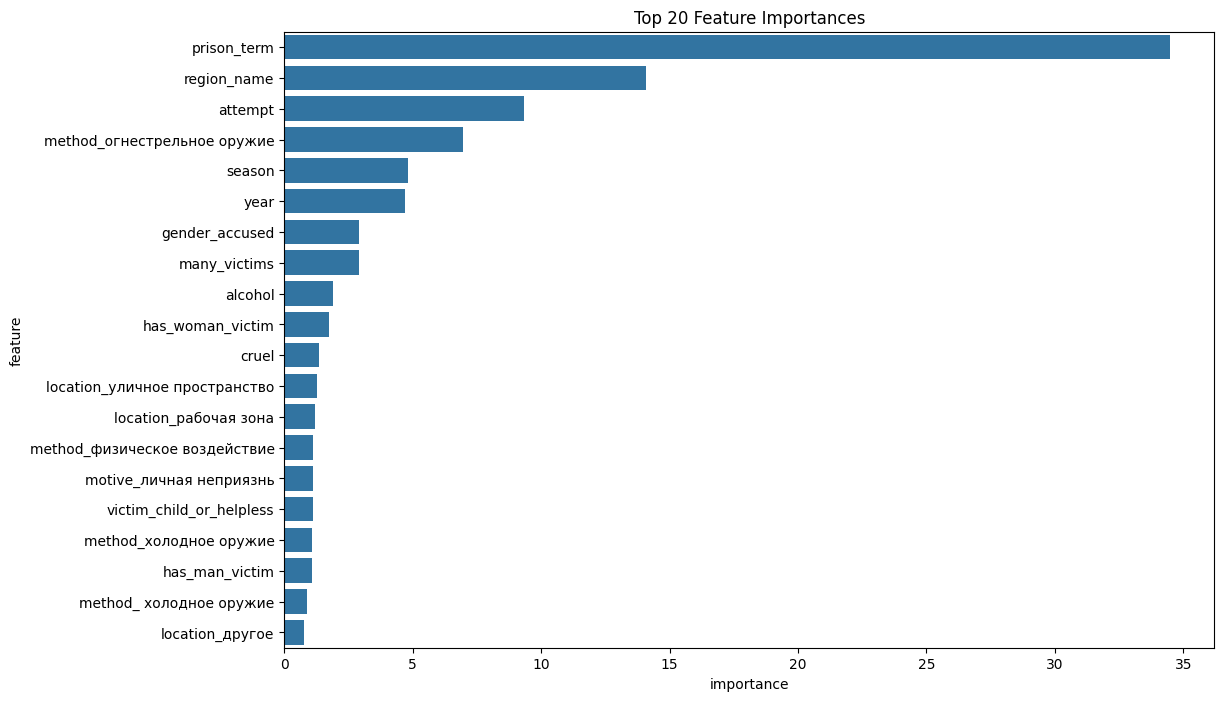

Top 11 features: ['prison_term', 'region_name', 'attempt', 'method_огнестрельное оружие', 'season', 'year', 'gender_accused', 'many_victims', 'alcohol', 'has_woman_victim', 'cruel']


In [ ]:
# Получаем важность признаков
feature_importances = model.get_feature_importance()
feature_names = X_train.columns

# Создаем DataFrame с важностью признаков
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances')
plt.show()

# Выбираем топ-11 признаков
top_features = importance_df.head(11)['feature'].tolist()
print("Top 11 features:", top_features)

In [ ]:
# Выбираем только важные признаки
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Обновляем список категориальных признаков (оставляем только те, что есть в топ-11)
categorical_features_top = [f for f in categorical_features if f in top_features]

# Оптимизация гиперпараметров для новой модели
def objective_top(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'class_weights': [1, trial.suggest_float('class_weight_positive', 1.0, 5.0)],
        'eval_metric': 'F1',
        'cat_features': categorical_features_top,
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    model.fit(X_train_top, y_train, eval_set=(X_test_top, y_test), verbose=0)
    
    preds = model.predict(X_test_top)
    f1 = f1_score(y_test, preds)
    return f1

study_top = optuna.create_study(direction='maximize')
study_top.optimize(objective_top, n_trials=50)

print('Лучшие параметры для топ-11 признаков:', study_top.best_params)

# Обучение финальной модели с лучшими параметрами
best_params_top = study_top.best_params

model_top = CatBoostClassifier(
    iterations=1000,
    learning_rate=best_params_top['learning_rate'],
    depth=best_params_top['depth'],
    l2_leaf_reg=best_params_top['l2_leaf_reg'],
    random_strength=best_params_top['random_strength'],
    bagging_temperature=best_params_top['bagging_temperature'],
    border_count=best_params_top['border_count'],
    class_weights=[1, best_params_top['class_weight_positive']],
    eval_metric='F1',
    cat_features=categorical_features_top,
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

model_top.fit(X_train_top, y_train, eval_set=(X_test_top, y_test))

# Оценка модели
y_pred_top = model_top.predict(X_test_top)

print("\nClassification Report for Top 11 Features Model:")
print(classification_report(y_test, y_pred_top))

# Сравнение с полной моделью
print("\nComparison with Full Model:")
full_model_f1 = f1_score(y_test, y_pred)
top_model_f1 = f1_score(y_test, y_pred_top)
print(f"Full model F1: {full_model_f1:.4f}")
print(f"Top 11 features model F1: {top_model_f1:.4f}")
print(f"Difference: {(top_model_f1 - full_model_f1):.4f}")

[I 2025-04-28 14:03:30,853] A new study created in memory with name: no-name-45f71a05-2817-4f72-9629-16f23a9a07ed
[I 2025-04-28 14:03:31,368] Trial 0 finished with value: 0.47586872586872586 and parameters: {'learning_rate': 0.10300710234782097, 'depth': 6, 'l2_leaf_reg': 5.64419796678527, 'random_strength': 2.881906664631811, 'bagging_temperature': 0.7092563002362334, 'border_count': 230, 'class_weight_positive': 2.5761001174230573}. Best is trial 0 with value: 0.47586872586872586.
[I 2025-04-28 14:03:32,172] Trial 1 finished with value: 0.5156565656565657 and parameters: {'learning_rate': 0.1674997137902023, 'depth': 7, 'l2_leaf_reg': 2.8486527148837713, 'random_strength': 0.49333327968388346, 'bagging_temperature': 0.017882884246158803, 'border_count': 94, 'class_weight_positive': 3.990835760437001}. Best is trial 1 with value: 0.5156565656565657.
[I 2025-04-28 14:03:32,713] Trial 2 finished with value: 0.5011612903225806 and parameters: {'learning_rate': 0.12456676221384116, 'depth

Лучшие параметры для топ-11 признаков: {'learning_rate': 0.11778010422721635, 'depth': 7, 'l2_leaf_reg': 6.390264385237643, 'random_strength': 2.4875422019662787, 'bagging_temperature': 0.44653907477063653, 'border_count': 136, 'class_weight_positive': 3.196658945764367}
0:	learn: 0.6177641	test: 0.6152566	best: 0.6152566 (0)	total: 4.55ms	remaining: 4.54s
100:	learn: 0.6657659	test: 0.6667903	best: 0.6667903 (100)	total: 946ms	remaining: 8.42s
200:	learn: 0.6929893	test: 0.6759446	best: 0.6785560 (191)	total: 1.83s	remaining: 7.29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.678555999
bestIteration = 191

Shrink model to first 192 iterations.

Classification Report for Top 11 Features Model:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      5435
           1       0.45      0.64      0.53      1518

    accuracy                           0.75      6953
   macro avg       0.67      0.71      0.68      6953
we

In [ ]:
import os
import joblib
import json
from catboost import CatBoostClassifier

# 1. Создаем папку для модели (если не существует)
model_dir = "prior_convictions_model"
os.makedirs(model_dir, exist_ok=True)

# 2. Сохраняем модель CatBoost
model_path = os.path.join(model_dir, "model.cbm")
model_top.save_model(model_path)

# 3. Сохраняем список важных признаков
top_features_path = os.path.join(model_dir, "top_features.json")
with open(top_features_path, 'w') as f:
    json.dump(top_features, f)

# 4. Сохраняем список категориальных признаков
cat_features_path = os.path.join(model_dir, "categorical_features.json")
with open(cat_features_path, 'w') as f:
    json.dump(categorical_features_top, f)

# 5. Сохраняем MultiLabelBinarizer
mlb_path = os.path.join(model_dir, "multilabel_binarizer.pkl")
joblib.dump(mlb, mlb_path)

# 6. Сохраняем метаданные (опционально)
metadata = {
    "model_type": "CatBoostClassifier",
    "version": "1.0",
    "date_created": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target_variable": "prior_convictions",
    "input_features": top_features
}

metadata_path = os.path.join(model_dir, "metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Все компоненты модели сохранены в папку: {model_dir}")

Все компоненты модели сохранены в папку: prior_convictions_model
